Dataset shape  : (737, 2)
Date range     : 2024-01-02 00:00:00 → 2026-01-07 00:00:00
Columns        : ['return', 'sentiment']
           return   sentiment
count  737.000000  737.000000
mean    -0.000649    0.854176
std      0.022182    0.175801
min     -0.114654    0.000000
25%     -0.007692    0.854176
50%      0.000000    0.854176
75%      0.006565    1.000000
max      0.222419    1.000000

Train size : 589
Test size  : 148

Fitting ARIMAX(1, 0, 1) with sentiment as exogenous variable...
                               SARIMAX Results                                
Dep. Variable:                 return   No. Observations:                  589
Model:               SARIMAX(1, 0, 1)   Log Likelihood                1428.625
Date:                Mon, 23 Feb 2026   AIC                          -2847.250
Time:                        03:25:49   BIC                          -2825.358
Sample:                    01-02-2024   HQIC                         -2838.721
                         - 08-

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  Step  30/148 | Date: 2025-09-11 | Actual: -0.01860 | Pred: 0.00216
  Step  40/148 | Date: 2025-09-21 | Actual: 0.00000 | Pred: -0.00085
  Step  50/148 | Date: 2025-10-01 | Actual: 0.01914 | Pred: -0.00072
  Step  60/148 | Date: 2025-10-11 | Actual: 0.00000 | Pred: 0.00528


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  Step  70/148 | Date: 2025-10-21 | Actual: -0.00568 | Pred: -0.00185
  Step  80/148 | Date: 2025-10-31 | Actual: -0.01341 | Pred: 0.00116


...

  Step  90/148 | Date: 2025-11-10 | Actual: 0.00760 | Pred: -0.00042


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  Step 100/148 | Date: 2025-11-20 | Actual: -0.11465 | Pred: 0.00296
  Step 110/148 | Date: 2025-11-30 | Actual: 0.00000 | Pred: -0.00064


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  Step 120/148 | Date: 2025-12-10 | Actual: -0.00261 | Pred: -0.00079
  Step 130/148 | Date: 2025-12-20 | Actual: 0.00000 | Pred: -0.00315
  Step 140/148 | Date: 2025-12-30 | Actual: -0.00246 | Pred: -0.00187

ARIMAX TEST PERFORMANCE
  RMSE            : 0.024939
  MAE             : 0.014569
  Directional Acc : 35.1%

MODEL                      RMSE        MAE    DIR ACC
--------------------------------------------------
ARIMAX(1,0,1)          0.024939   0.014569      35.1%


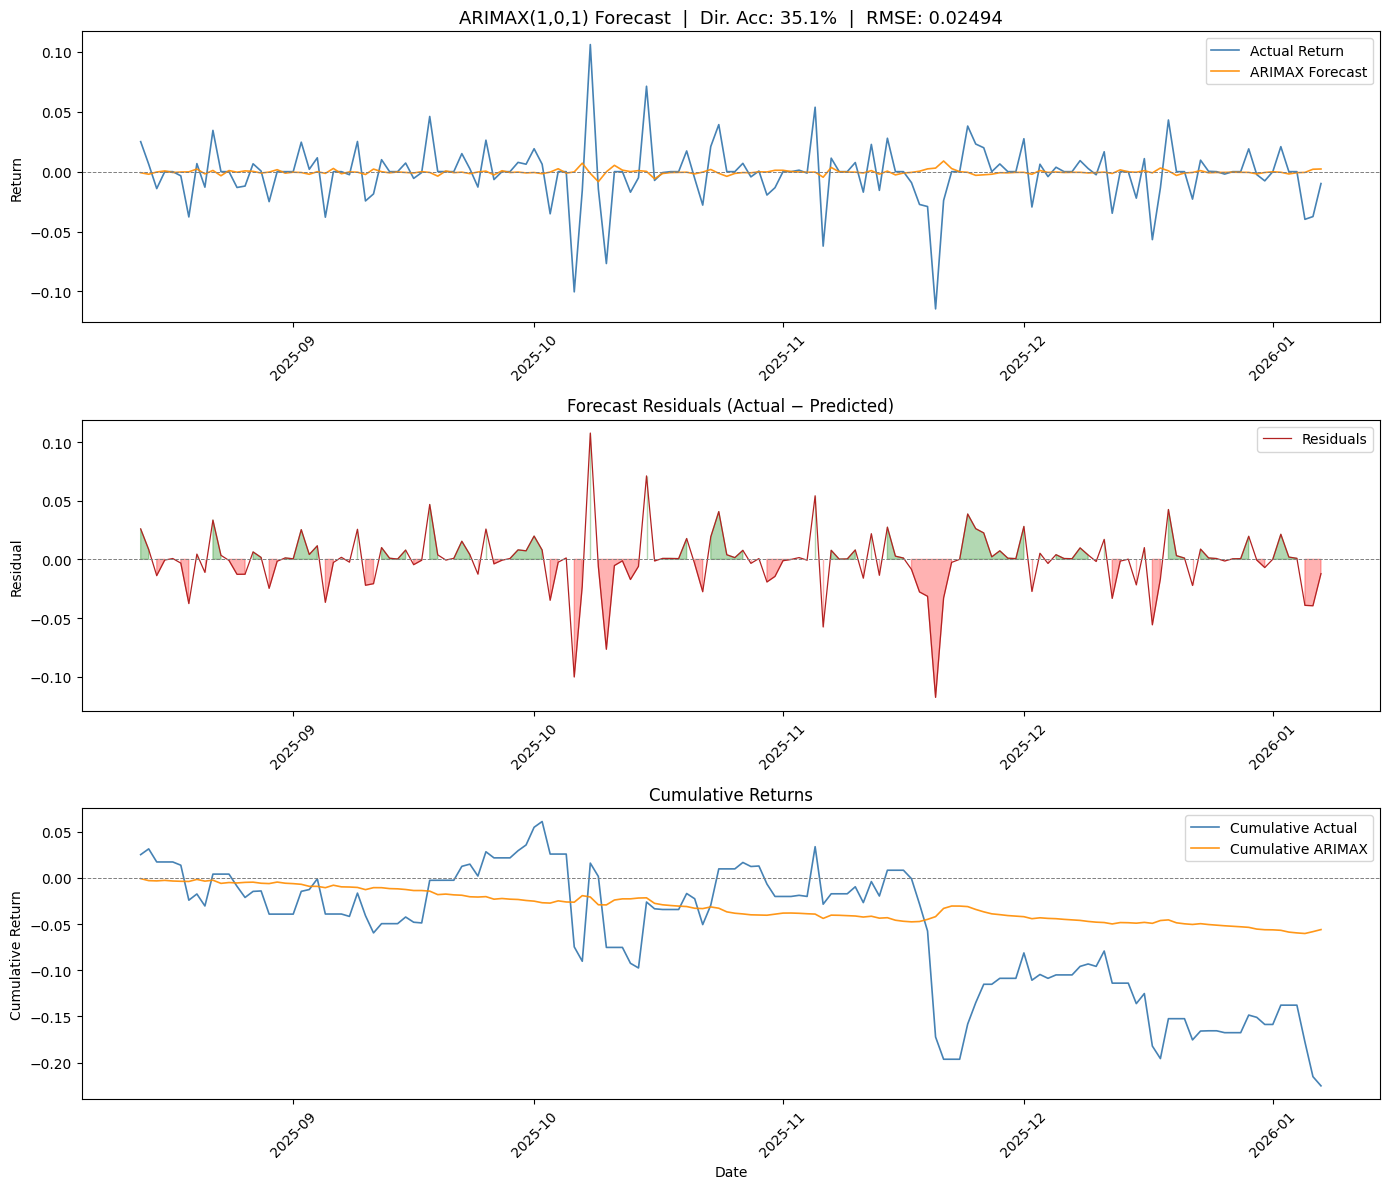

In [ ]:
# ================================
# ARIMAX FORECAST
# p=1, d=0, q=1
# Exogenous: sentiment
# Target: return
# Metrics: RMSE, MAE, Directional Accuracy
# ================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tools.sm_exceptions import ValueWarning
warnings.simplefilter('ignore', ValueWarning)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_error


# ================================
# LOAD DATA
# ================================

file_path = "/content/dataset_title_post_full.xlsx"

df = pd.read_excel(file_path)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df = df.set_index('date')

print("Dataset shape  :", df.shape)
print("Date range     :", df.index.min(), "→", df.index.max())
print("Columns        :", df.columns.tolist())
print(df[['return', 'sentiment']].describe())


# ================================
# TRAIN / TEST SPLIT
# ================================

split = int(len(df) * 0.8)

train = df.iloc[:split]
test  = df.iloc[split:]

y_train = train['return']
y_test  = test['return']

exog_train = train[['sentiment']]
exog_test  = test[['sentiment']]

print(f"\nTrain size : {len(train)}")
print(f"Test size  : {len(test)}")


# ================================
# FIT ARIMAX(1, 0, 1)
# SARIMAX is statsmodels' unified interface for ARIMAX
# ================================

print("\nFitting ARIMAX(1, 0, 1) with sentiment as exogenous variable...")

model = SARIMAX(
    y_train,
    exog=exog_train,
    order=(1, 0, 1),          # p=1, d=0, q=1 from ACF/PACF
    trend='c',                # include constant (intercept)
    enforce_stationarity=True,
    enforce_invertibility=True
)

result = model.fit(disp=False)

print(result.summary())


# ================================
# RESIDUAL DIAGNOSTICS
# Ljung-Box test: checks if residuals are white noise
# p-value > 0.05 = residuals are white noise = good fit
# ================================

lb_test = acorr_ljungbox(result.resid, lags=[10], return_df=True)
print(f"\nLjung-Box Test (lag=10):")
print(f"  Statistic : {lb_test['lb_stat'].values[0]:.4f}")
print(f"  p-value   : {lb_test['lb_pvalue'].values[0]:.4f}")
print(f"  Verdict   : {'✅ Residuals are white noise (good)' if lb_test['lb_pvalue'].values[0] > 0.05 else '⚠️ Residuals have remaining autocorrelation'}")


# ================================
# ONE-STEP-AHEAD FORECAST (rolling)
# For fair comparison with GA-LSTM v2:
# At each test step, refit on all available data up to that point
# and predict one step ahead using the real exogenous value.
# This mirrors how GA-LSTM v2 uses real inputs at each step.
# ================================

print("\nRunning one-step-ahead rolling forecast...")

predictions = []
actuals     = []
pred_dates  = []

for i in range(len(test)):
    # Expanding window: train + all test steps seen so far
    train_end   = split + i
    y_window    = df['return'].iloc[:train_end]
    exog_window = df[['sentiment']].iloc[:train_end]

    # One future step
    exog_future = df[['sentiment']].iloc[[train_end]]

    try:
        mdl = SARIMAX(
            y_window,
            exog=exog_window,
            order=(1, 0, 1),
            trend='c',
            enforce_stationarity=True,
            enforce_invertibility=True
        )
        res  = mdl.fit(disp=False)
        pred = res.forecast(steps=1, exog=exog_future).values[0]
    except Exception:
        pred = 0.0

    predictions.append(pred)
    actuals.append(df['return'].iloc[train_end])
    pred_dates.append(df.index[train_end])

    if (i + 1) % 10 == 0 or i == 0:
        print(f"  Step {i+1:>3}/{len(test)} | Date: {pred_dates[-1].date()} | "
              f"Actual: {actuals[-1]:.5f} | Pred: {predictions[-1]:.5f}")

predictions = np.array(predictions)
actuals     = np.array(actuals)
pred_dates  = pd.to_datetime(pred_dates)


# ================================
# METRICS
# ================================

rmse    = np.sqrt(mean_squared_error(actuals, predictions))
mae     = mean_absolute_error(actuals, predictions)
dir_acc = np.mean(np.sign(actuals) == np.sign(predictions)) * 100

print(f"\n{'=' * 40}")
print(f"ARIMAX TEST PERFORMANCE")
print(f"{'=' * 40}")
print(f"  RMSE            : {rmse:.6f}")
print(f"  MAE             : {mae:.6f}")
print(f"  Directional Acc : {dir_acc:.1f}%")
print(f"{'=' * 40}")


# ================================
# COMPARISON TABLE vs GA-LSTM v2
# Fill in your GA-LSTM v2 results here
# ================================

print(f"\n{'=' * 50}")
print(f"{'MODEL':<20} {'RMSE':>10} {'MAE':>10} {'DIR ACC':>10}")
print(f"{'-' * 50}")
print(f"{'ARIMAX(1,0,1)':<20} {rmse:>10.6f} {mae:>10.6f} {dir_acc:>9.1f}%")
print(f"{'=' * 50}")


# ================================
# PLOT
# ================================

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# --- Forecast vs Actual ---
ax1 = axes[0]
ax1.plot(pred_dates, actuals,     label='Actual Return',   color='steelblue',  linewidth=1.2)
ax1.plot(pred_dates, predictions, label='ARIMAX Forecast', color='darkorange', linewidth=1.2, alpha=0.9)
ax1.axhline(0, color='gray', linewidth=0.7, linestyle='--')
ax1.set_title(f"ARIMAX(1,0,1) Forecast  |  Dir. Acc: {dir_acc:.1f}%  |  RMSE: {rmse:.5f}", fontsize=13)
ax1.set_ylabel("Return")
ax1.legend()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.tick_params(axis='x', rotation=45)

# --- Residuals ---
ax2 = axes[1]
residuals = actuals - predictions
ax2.plot(pred_dates, residuals, color='firebrick', linewidth=0.9, label='Residuals')
ax2.axhline(0, color='gray', linewidth=0.7, linestyle='--')
ax2.fill_between(pred_dates, residuals, 0,
                 where=(residuals >= 0), alpha=0.3, color='green')
ax2.fill_between(pred_dates, residuals, 0,
                 where=(residuals < 0),  alpha=0.3, color='red')
ax2.set_title("Forecast Residuals (Actual − Predicted)")
ax2.set_ylabel("Residual")
ax2.legend()
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.tick_params(axis='x', rotation=45)

# --- Cumulative returns ---
ax3 = axes[2]
ax3.plot(pred_dates, np.cumsum(actuals),     label='Cumulative Actual',  color='steelblue',  linewidth=1.2)
ax3.plot(pred_dates, np.cumsum(predictions), label='Cumulative ARIMAX',  color='darkorange', linewidth=1.2, alpha=0.9)
ax3.axhline(0, color='gray', linewidth=0.7, linestyle='--')
ax3.set_title("Cumulative Returns")
ax3.set_ylabel("Cumulative Return")
ax3.set_xlabel("Date")
ax3.legend()
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax3.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("arimax_forecast.png", dpi=150)
plt.show()

In [ ]:
# ================================
# EXTENSION: ARIMAX Y EQUATION
# Run this in a new cell after the main ARIMAX code
# 'result' must already be in memory
# ================================

import numpy as np

params    = result.params
pvalues   = result.pvalues

const     = params.get('const',     params.get('intercept', 0))
ar1       = params.get('ar.L1',     0)
ma1       = params.get('ma.L1',     0)
sentiment = params.get('sentiment', 0)

p_const     = pvalues.get('const',     pvalues.get('intercept', np.nan))
p_ar1       = pvalues.get('ar.L1',     np.nan)
p_ma1       = pvalues.get('ma.L1',     np.nan)
p_sentiment = pvalues.get('sentiment', np.nan)

print(f"{'=' * 55}")
print(f"ARIMAX(1,0,1) — Y EQUATION")
print(f"{'=' * 55}")
print(f"  return_t = {const:+.6f}")
print(f"           {ar1:+.6f} × return_(t-1)    [AR term]")
print(f"           {ma1:+.6f} × error_(t-1)     [MA term]")
print(f"           {sentiment:+.6f} × sentiment_t     [Exogenous]")
print(f"{'=' * 55}")

print(f"\nCoefficient Significance (p < 0.05 = significant):")
print(f"  {'Parameter':<20} {'Coeff':>10} {'p-value':>10} {'Sig':>8}")
print(f"  {'-' * 52}")
for name, coef, pval in zip(
    ['Intercept', 'AR(1)', 'MA(1)', 'Sentiment'],
    [const, ar1, ma1, sentiment],
    [p_const, p_ar1, p_ma1, p_sentiment]
):
    sig = '✅ Yes' if pval < 0.05 else '❌ No'
    print(f"  {name:<20} {coef:>10.6f} {pval:>10.4f} {sig:>8}")

ARIMAX(1,0,1) — Y EQUATION
  return_t = -0.000294
           -0.382121 × return_(t-1)    [AR term]
           +0.306854 × error_(t-1)     [MA term]
           -0.000257 × sentiment_t     [Exogenous]

Coefficient Significance (p < 0.05 = significant):
  Parameter                 Coeff    p-value      Sig
  ----------------------------------------------------
  Intercept             -0.000294     0.9733     ❌ No
  AR(1)                 -0.382121     0.4625     ❌ No
  MA(1)                  0.306854     0.5662     ❌ No
  Sentiment             -0.000257     0.9714     ❌ No


Dataset shape  : (737, 2)
Date range     : 2024-01-02 00:00:00 → 2026-01-07 00:00:00
Columns        : ['return', 'sentiment']
           return   sentiment
count  737.000000  737.000000
mean    -0.000649   -0.032163
std      0.022182    0.196287
min     -0.114654   -1.000000
25%     -0.007692   -0.032163
50%      0.000000   -0.032163
75%      0.006565    0.000000
max      0.222419    1.000000

Train size : 589
Test size  : 148

Fitting ARIMAX(1, 0, 1) with sentiment as exogenous variable...
                               SARIMAX Results                                
Dep. Variable:                 return   No. Observations:                  589
Model:               SARIMAX(1, 0, 1)   Log Likelihood                1428.781
Date:                Mon, 23 Feb 2026   AIC                          -2847.561
Time:                        03:26:54   BIC                          -2825.669
Sample:                    01-02-2024   HQIC                         -2839.032
                         - 08-

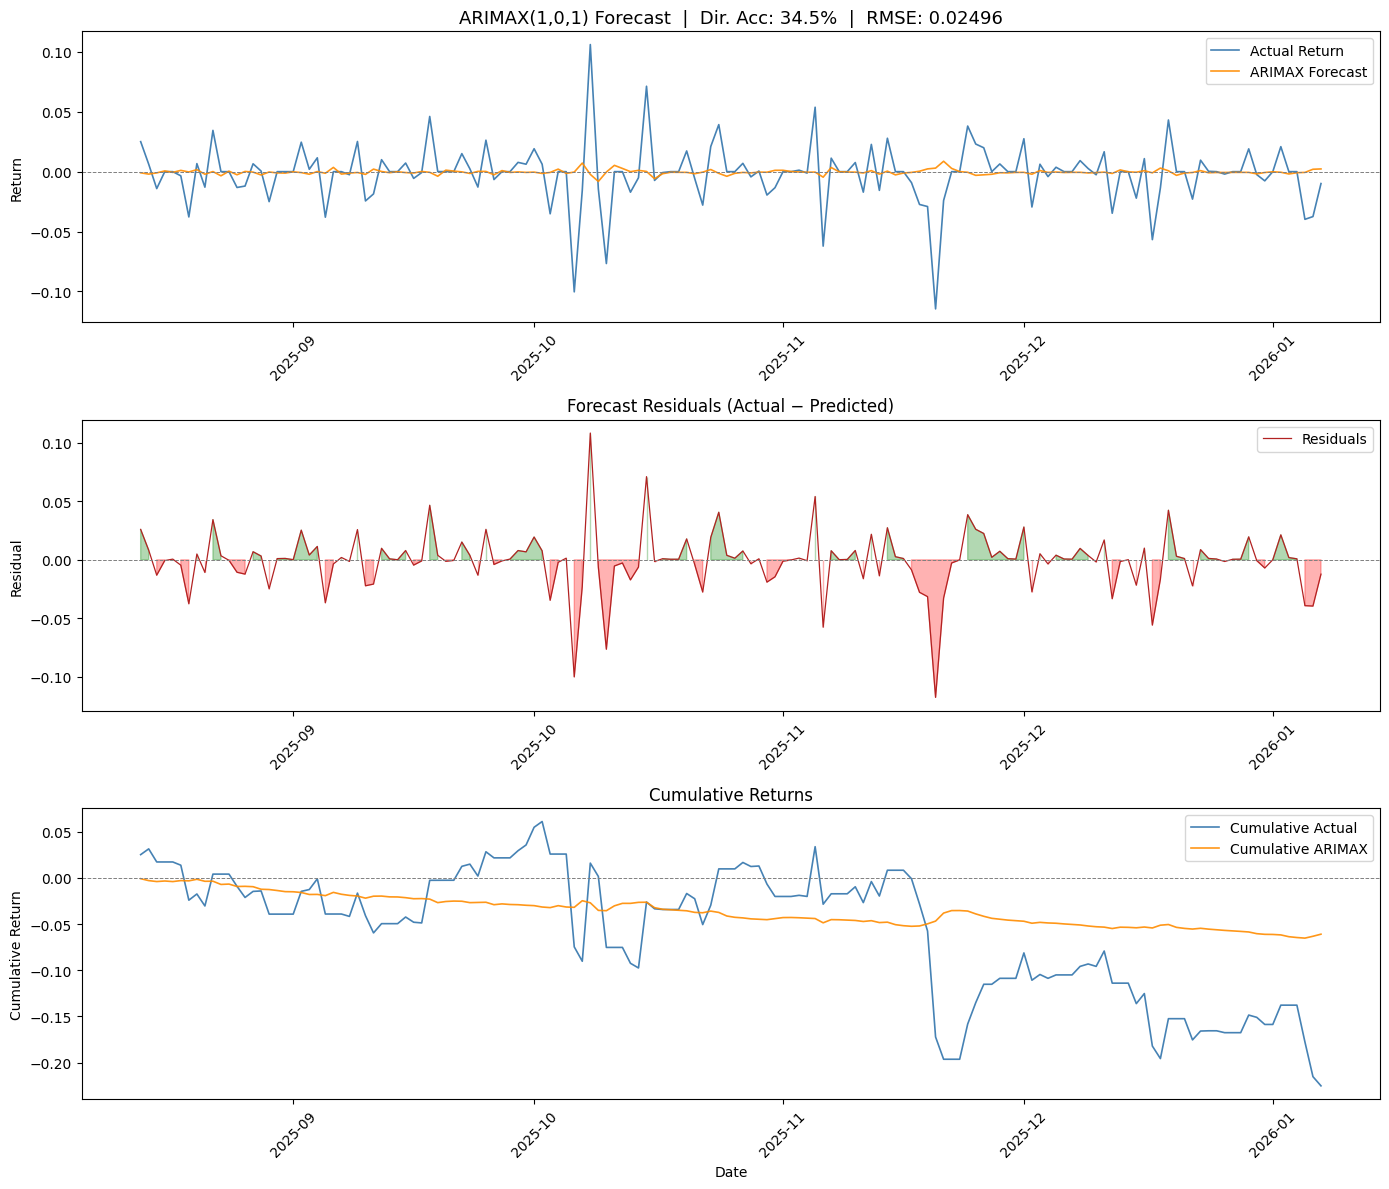

In [ ]:
# ================================
# ARIMAX FORECAST
# p=1, d=0, q=1
# Exogenous: sentiment
# Target: return
# Metrics: RMSE, MAE, Directional Accuracy
# ================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tools.sm_exceptions import ValueWarning
warnings.simplefilter('ignore', ValueWarning)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_error


# ================================
# LOAD DATA
# ================================

file_path = "/content/dataset_title_only_full.xlsx"

df = pd.read_excel(file_path)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df = df.set_index('date')

print("Dataset shape  :", df.shape)
print("Date range     :", df.index.min(), "→", df.index.max())
print("Columns        :", df.columns.tolist())
print(df[['return', 'sentiment']].describe())


# ================================
# TRAIN / TEST SPLIT
# ================================

split = int(len(df) * 0.8)

train = df.iloc[:split]
test  = df.iloc[split:]

y_train = train['return']
y_test  = test['return']

exog_train = train[['sentiment']]
exog_test  = test[['sentiment']]

print(f"\nTrain size : {len(train)}")
print(f"Test size  : {len(test)}")


# ================================
# FIT ARIMAX(1, 0, 1)
# SARIMAX is statsmodels' unified interface for ARIMAX
# ================================

print("\nFitting ARIMAX(1, 0, 1) with sentiment as exogenous variable...")

model = SARIMAX(
    y_train,
    exog=exog_train,
    order=(1, 0, 1),          # p=1, d=0, q=1 from ACF/PACF
    trend='c',                # include constant (intercept)
    enforce_stationarity=True,
    enforce_invertibility=True
)

result = model.fit(disp=False)

print(result.summary())


# ================================
# RESIDUAL DIAGNOSTICS
# Ljung-Box test: checks if residuals are white noise
# p-value > 0.05 = residuals are white noise = good fit
# ================================

lb_test = acorr_ljungbox(result.resid, lags=[10], return_df=True)
print(f"\nLjung-Box Test (lag=10):")
print(f"  Statistic : {lb_test['lb_stat'].values[0]:.4f}")
print(f"  p-value   : {lb_test['lb_pvalue'].values[0]:.4f}")
print(f"  Verdict   : {'✅ Residuals are white noise (good)' if lb_test['lb_pvalue'].values[0] > 0.05 else '⚠️ Residuals have remaining autocorrelation'}")


# ================================
# ONE-STEP-AHEAD FORECAST (rolling)
# For fair comparison with GA-LSTM v2:
# At each test step, refit on all available data up to that point
# and predict one step ahead using the real exogenous value.
# This mirrors how GA-LSTM v2 uses real inputs at each step.
# ================================

print("\nRunning one-step-ahead rolling forecast...")

predictions = []
actuals     = []
pred_dates  = []

for i in range(len(test)):
    # Expanding window: train + all test steps seen so far
    train_end   = split + i
    y_window    = df['return'].iloc[:train_end]
    exog_window = df[['sentiment']].iloc[:train_end]

    # One future step
    exog_future = df[['sentiment']].iloc[[train_end]]

    try:
        mdl = SARIMAX(
            y_window,
            exog=exog_window,
            order=(1, 0, 1),
            trend='c',
            enforce_stationarity=True,
            enforce_invertibility=True
        )
        res  = mdl.fit(disp=False)
        pred = res.forecast(steps=1, exog=exog_future).values[0]
    except Exception:
        pred = 0.0

    predictions.append(pred)
    actuals.append(df['return'].iloc[train_end])
    pred_dates.append(df.index[train_end])

    if (i + 1) % 10 == 0 or i == 0:
        print(f"  Step {i+1:>3}/{len(test)} | Date: {pred_dates[-1].date()} | "
              f"Actual: {actuals[-1]:.5f} | Pred: {predictions[-1]:.5f}")

predictions = np.array(predictions)
actuals     = np.array(actuals)
pred_dates  = pd.to_datetime(pred_dates)


# ================================
# METRICS
# ================================

rmse    = np.sqrt(mean_squared_error(actuals, predictions))
mae     = mean_absolute_error(actuals, predictions)
dir_acc = np.mean(np.sign(actuals) == np.sign(predictions)) * 100

print(f"\n{'=' * 40}")
print(f"ARIMAX TEST PERFORMANCE")
print(f"{'=' * 40}")
print(f"  RMSE            : {rmse:.6f}")
print(f"  MAE             : {mae:.6f}")
print(f"  Directional Acc : {dir_acc:.1f}%")
print(f"{'=' * 40}")


# ================================
# COMPARISON TABLE vs GA-LSTM v2
# Fill in your GA-LSTM v2 results here
# ================================

print(f"\n{'=' * 50}")
print(f"{'MODEL':<20} {'RMSE':>10} {'MAE':>10} {'DIR ACC':>10}")
print(f"{'-' * 50}")
print(f"{'ARIMAX(1,0,1)':<20} {rmse:>10.6f} {mae:>10.6f} {dir_acc:>9.1f}%")
print(f"{'=' * 50}")


# ================================
# PLOT
# ================================

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# --- Forecast vs Actual ---
ax1 = axes[0]
ax1.plot(pred_dates, actuals,     label='Actual Return',   color='steelblue',  linewidth=1.2)
ax1.plot(pred_dates, predictions, label='ARIMAX Forecast', color='darkorange', linewidth=1.2, alpha=0.9)
ax1.axhline(0, color='gray', linewidth=0.7, linestyle='--')
ax1.set_title(f"ARIMAX(1,0,1) Forecast  |  Dir. Acc: {dir_acc:.1f}%  |  RMSE: {rmse:.5f}", fontsize=13)
ax1.set_ylabel("Return")
ax1.legend()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.tick_params(axis='x', rotation=45)

# --- Residuals ---
ax2 = axes[1]
residuals = actuals - predictions
ax2.plot(pred_dates, residuals, color='firebrick', linewidth=0.9, label='Residuals')
ax2.axhline(0, color='gray', linewidth=0.7, linestyle='--')
ax2.fill_between(pred_dates, residuals, 0,
                 where=(residuals >= 0), alpha=0.3, color='green')
ax2.fill_between(pred_dates, residuals, 0,
                 where=(residuals < 0),  alpha=0.3, color='red')
ax2.set_title("Forecast Residuals (Actual − Predicted)")
ax2.set_ylabel("Residual")
ax2.legend()
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.tick_params(axis='x', rotation=45)

# --- Cumulative returns ---
ax3 = axes[2]
ax3.plot(pred_dates, np.cumsum(actuals),     label='Cumulative Actual',  color='steelblue',  linewidth=1.2)
ax3.plot(pred_dates, np.cumsum(predictions), label='Cumulative ARIMAX',  color='darkorange', linewidth=1.2, alpha=0.9)
ax3.axhline(0, color='gray', linewidth=0.7, linestyle='--')
ax3.set_title("Cumulative Returns")
ax3.set_ylabel("Cumulative Return")
ax3.set_xlabel("Date")
ax3.legend()
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax3.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("arimax_forecast.png", dpi=150)
plt.show()

In [ ]:
# ================================
# EXTENSION: ARIMAX Y EQUATION
# Run this in a new cell after the main ARIMAX code
# 'result' must already be in memory
# ================================

import numpy as np

params    = result.params
pvalues   = result.pvalues

const     = params.get('const',     params.get('intercept', 0))
ar1       = params.get('ar.L1',     0)
ma1       = params.get('ma.L1',     0)
sentiment = params.get('sentiment', 0)

p_const     = pvalues.get('const',     pvalues.get('intercept', np.nan))
p_ar1       = pvalues.get('ar.L1',     np.nan)
p_ma1       = pvalues.get('ma.L1',     np.nan)
p_sentiment = pvalues.get('sentiment', np.nan)

print(f"{'=' * 55}")
print(f"ARIMAX(1,0,1) — Y EQUATION")
print(f"{'=' * 55}")
print(f"  return_t = {const:+.6f}")
print(f"           {ar1:+.6f} × return_(t-1)    [AR term]")
print(f"           {ma1:+.6f} × error_(t-1)     [MA term]")
print(f"           {sentiment:+.6f} × sentiment_t     [Exogenous]")
print(f"{'=' * 55}")

print(f"\nCoefficient Significance (p < 0.05 = significant):")
print(f"  {'Parameter':<20} {'Coeff':>10} {'p-value':>10} {'Sig':>8}")
print(f"  {'-' * 52}")
for name, coef, pval in zip(
    ['Intercept', 'AR(1)', 'MA(1)', 'Sentiment'],
    [const, ar1, ma1, sentiment],
    [p_const, p_ar1, p_ma1, p_sentiment]
):
    sig = '✅ Yes' if pval < 0.05 else '❌ No'
    print(f"  {name:<20} {coef:>10.6f} {pval:>10.4f} {sig:>8}")

ARIMAX(1,0,1) — Y EQUATION
  return_t = -0.000490
           -0.381023 × return_(t-1)    [AR term]
           +0.306866 × error_(t-1)     [MA term]
           +0.002479 × sentiment_t     [Exogenous]

Coefficient Significance (p < 0.05 = significant):
  Parameter                 Coeff    p-value      Sig
  ----------------------------------------------------
  Intercept             -0.000490     0.7062     ❌ No
  AR(1)                 -0.381023     0.4736     ❌ No
  MA(1)                  0.306866     0.5746     ❌ No
  Sentiment              0.002479     0.6447     ❌ No
